# Regresión Logística: Análisis de Comportamiento de Compra Online

Este notebook analiza el comportamiento de compra en una tienda online usando regresión logística multinomial.

**Objetivo:** Determinar los factores que influyen en la decisión de compra de una persona:
- Comprar ahora
- Comprar después  
- No comprar nada

**Variables predictoras:**
- Sexo
- Edad
- Tiempo en la tienda online

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# Cargar los datos
df = pd.read_csv('datatab.csv')

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación general del dataset:")
print(df.info())
print("\nValores únicos por columna:")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Dimensiones del dataset: (24, 4)

Primeras 5 filas:
  Hábito de compra    Sexo  Edad  Tiempo en la tienda online
0    Comprar ahora   mujer    22                          40
1    Comprar ahora   mujer    25                          23
2    Comprar ahora  hombre    18                          12
3    Comprar ahora  hombre    45                          28
4    Comprar ahora   mujer    12                          43

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hábito de compra            24 non-null     object
 1   Sexo                        24 non-null     object
 2   Edad                        24 non-null     int64 
 3   Tiempo en la tienda online  24 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 900.0+ bytes
None

Valores únicos por columna:
Hábito de compra: ['C

In [3]:
# Análisis exploratorio de datos
print("Distribución de la variable objetivo:")
print(df['Hábito de compra'].value_counts())
print("\nPorcentajes:")
print(df['Hábito de compra'].value_counts(normalize=True) * 100)

# Estadísticas descriptivas
print("\n" + "="*50)
print("Estadísticas descriptivas:")
print(df.describe())

Distribución de la variable objetivo:
Hábito de compra
Comprar ahora      8
Comprar después    8
No comprar nada    8
Name: count, dtype: int64

Porcentajes:
Hábito de compra
Comprar ahora      33.333333
Comprar después    33.333333
No comprar nada    33.333333
Name: proportion, dtype: float64

Estadísticas descriptivas:
            Edad  Tiempo en la tienda online
count  24.000000                   24.000000
mean   37.583333                   42.250000
std    17.385443                   23.532124
min    12.000000                   11.000000
25%    26.500000                   26.750000
50%    33.500000                   37.000000
75%    44.250000                   55.250000
max    88.000000                  110.000000


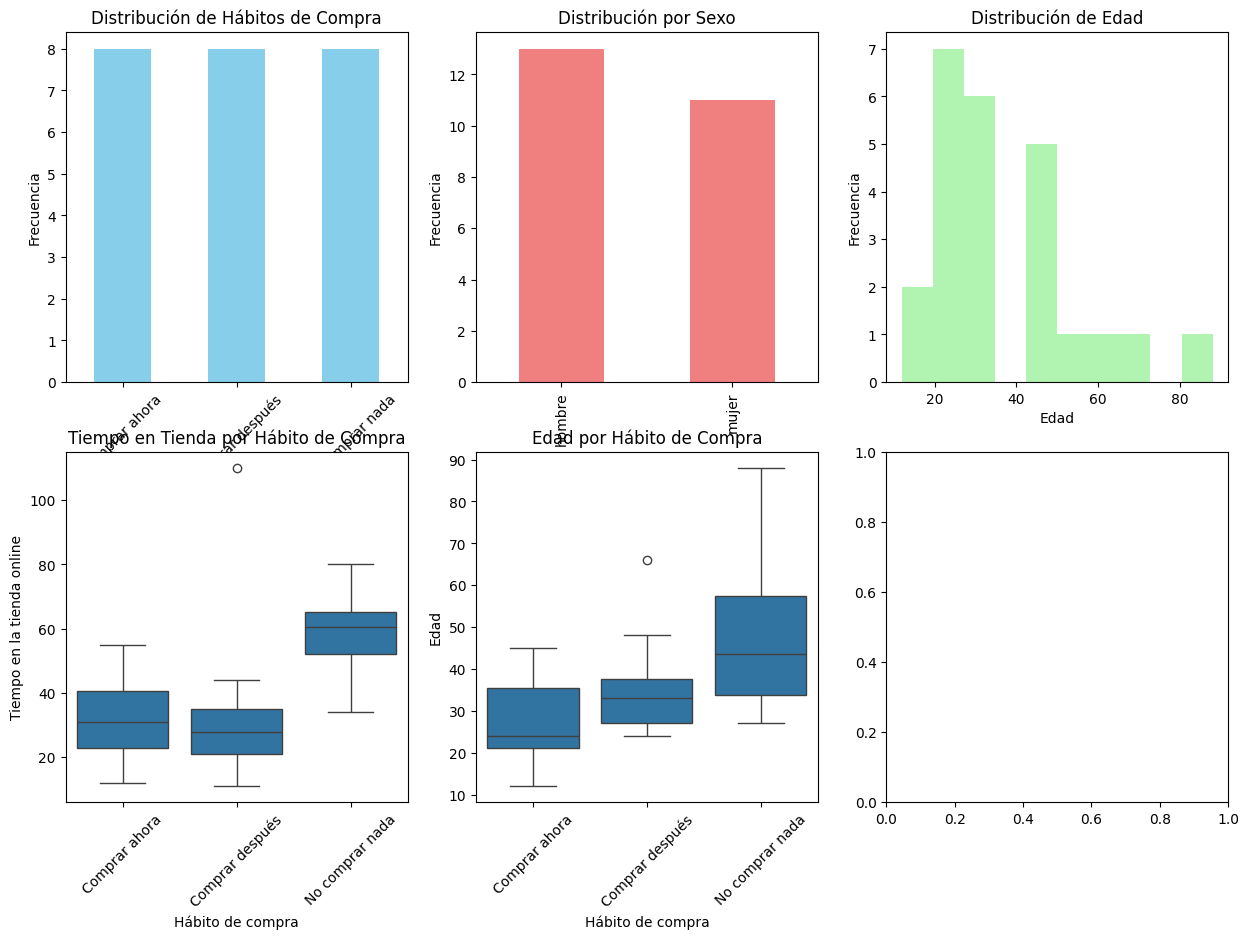

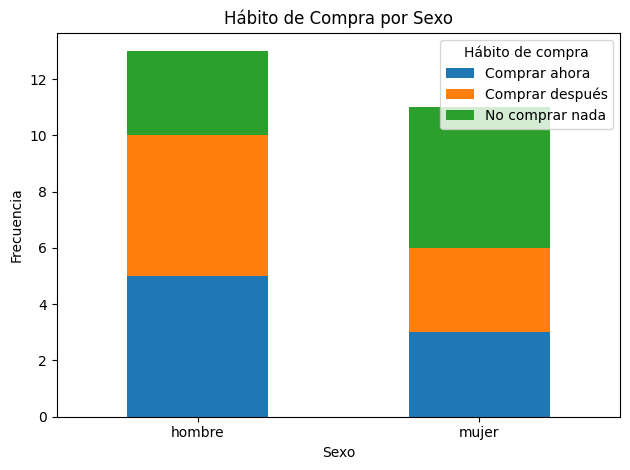

In [4]:
# Visualizaciones exploratorias
plt.figure(figsize=(15, 10))

# Distribución de hábitos de compra
plt.subplot(2, 3, 1)
df['Hábito de compra'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Hábitos de Compra')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)

# Distribución por sexo
plt.subplot(2, 3, 2)
df['Sexo'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Distribución por Sexo')
plt.ylabel('Frecuencia')

# Distribución de edad
plt.subplot(2, 3, 3)
plt.hist(df['Edad'], bins=10, color='lightgreen', alpha=0.7)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Tiempo en tienda por hábito de compra
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='Hábito de compra', y='Tiempo en la tienda online')
plt.xticks(rotation=45)
plt.title('Tiempo en Tienda por Hábito de Compra')

# Edad por hábito de compra
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='Hábito de compra', y='Edad')
plt.xticks(rotation=45)
plt.title('Edad por Hábito de Compra')

# Hábito de compra por sexo
plt.subplot(2, 3, 6)
pd.crosstab(df['Sexo'], df['Hábito de compra']).plot(kind='bar', stacked=True)
plt.title('Hábito de Compra por Sexo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [5]:
# Preparación de datos
df_processed = df.copy()

# Codificar variable sexo (0: hombre, 1: mujer)
le_sexo = LabelEncoder()
df_processed['Sexo_encoded'] = le_sexo.fit_transform(df_processed['Sexo'])

# Codificar variable objetivo
le_target = LabelEncoder()
df_processed['Target_encoded'] = le_target.fit_transform(df_processed['Hábito de compra'])

print("Mapeo de la variable Sexo:")
for i, clase in enumerate(le_sexo.classes_):
    print(f"{clase}: {i}")

print("\nMapeo de la variable objetivo:")
for i, clase in enumerate(le_target.classes_):
    print(f"{clase}: {i}")

# Definir variables predictoras y objetivo
X = df_processed[['Sexo_encoded', 'Edad', 'Tiempo en la tienda online']]
y = df_processed['Target_encoded']

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nPrimeras 5 filas de X:")
print(X.head())

Mapeo de la variable Sexo:
hombre: 0
mujer: 1

Mapeo de la variable objetivo:
Comprar ahora: 0
Comprar después: 1
No comprar nada: 2

Dimensiones de X: (24, 3)
Dimensiones de y: (24,)

Primeras 5 filas de X:
   Sexo_encoded  Edad  Tiempo en la tienda online
0             1    22                          40
1             1    25                          23
2             0    18                          12
3             0    45                          28
4             1    12                          43


In [6]:
# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño conjunto de prueba: {X_test.shape[0]} muestras")

# Normalización de variables numéricas
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Normalizar edad y tiempo en tienda (mantener sexo sin normalizar ya que es binario)
columns_to_scale = ['Edad', 'Tiempo en la tienda online']
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print(f"\nDatos normalizados:")
print(f"Media entrenamiento: {X_train_scaled[columns_to_scale].mean()}")
print(f"Desviación estándar entrenamiento: {X_train_scaled[columns_to_scale].std()}")

Tamaño conjunto de entrenamiento: 16 muestras
Tamaño conjunto de prueba: 8 muestras

Datos normalizados:
Media entrenamiento: Edad                         -1.387779e-17
Tiempo en la tienda online   -1.387779e-17
dtype: float64
Desviación estándar entrenamiento: Edad                          1.032796
Tiempo en la tienda online    1.032796
dtype: float64


In [7]:
# Crear y entrenar el modelo de regresión logística
# Para clasificación multinomial usamos solver='lbfgs' y multi_class='multinomial'
logistic_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42,
    max_iter=1000
)

# Entrenar el modelo
logistic_model.fit(X_train_scaled, y_train)

print("Modelo entrenado exitosamente:")
print(f"Clases del modelo: {logistic_model.classes_}")
print(f"Número de iteraciones: {logistic_model.n_iter_}")

Modelo entrenado exitosamente:
Clases del modelo: [0 1 2]
Número de iteraciones: [11]


In [8]:
# Hacer predicciones
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)

# Calcular precisión
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Mostrar predicciones vs valores reales
print(f"\nComparación de predicciones:")
comparison_df = pd.DataFrame({
    'Real': [le_target.inverse_transform([val])[0] for val in y_test],
    'Predicho': [le_target.inverse_transform([val])[0] for val in y_pred],
    'Correcto': y_test.values == y_pred
})
print(comparison_df)

Precisión del modelo: 0.2500 (25.00%)

Comparación de predicciones:
              Real         Predicho  Correcto
0    Comprar ahora  No comprar nada     False
1    Comprar ahora    Comprar ahora      True
2  Comprar después  No comprar nada     False
3  Comprar después    Comprar ahora     False
4  Comprar después  No comprar nada     False
5  No comprar nada  Comprar después     False
6  No comprar nada  No comprar nada      True
7  No comprar nada  Comprar después     False


1. MATRIZ DE CONFUSIÓN
                       Pred: Comprar ahora  Pred: Comprar después  \
Real: Comprar ahora                      1                      0   
Real: Comprar después                    1                      0   
Real: No comprar nada                    0                      2   

                       Pred: No comprar nada  
Real: Comprar ahora                        1  
Real: Comprar después                      2  
Real: No comprar nada                      1  


<Figure size 1000x800 with 0 Axes>

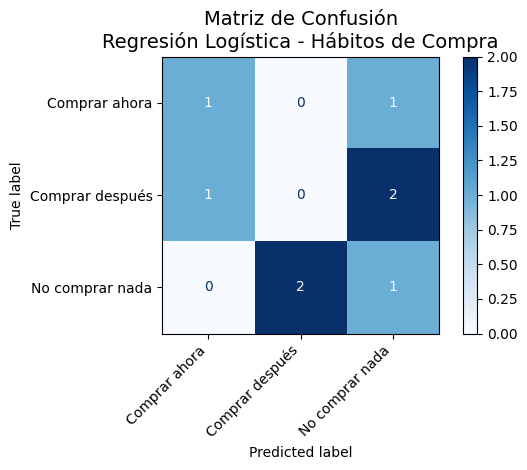

In [9]:
# 1. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
class_names = le_target.classes_

print("="*60)
print("1. MATRIZ DE CONFUSIÓN")
print("="*60)

# Crear DataFrame para mejor visualización
cm_df = pd.DataFrame(cm, 
                     index=[f'Real: {name}' for name in class_names],
                     columns=[f'Pred: {name}' for name in class_names])
print(cm_df)

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión\nRegresión Logística - Hábitos de Compra', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# 2. REPORTE DE CLASIFICACIÓN
print("\n" + "="*60)
print("2. REPORTE DE CLASIFICACIÓN")
print("="*60)

# Generar reporte
report = classification_report(y_test, y_pred, 
                             target_names=class_names, 
                             digits=4)
print(report)

# Reporte en formato DataFrame para mejor visualización
report_dict = classification_report(y_test, y_pred, 
                                  target_names=class_names, 
                                  output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("\nReporte en formato tabla:")
print(report_df.round(4))


2. REPORTE DE CLASIFICACIÓN
                 precision    recall  f1-score   support

  Comprar ahora     0.5000    0.5000    0.5000         2
Comprar después     0.0000    0.0000    0.0000         3
No comprar nada     0.2500    0.3333    0.2857         3

       accuracy                         0.2500         8
      macro avg     0.2500    0.2778    0.2619         8
   weighted avg     0.2188    0.2500    0.2321         8


Reporte en formato tabla:
                 precision  recall  f1-score  support
Comprar ahora       0.5000  0.5000    0.5000     2.00
Comprar después     0.0000  0.0000    0.0000     3.00
No comprar nada     0.2500  0.3333    0.2857     3.00
accuracy            0.2500  0.2500    0.2500     0.25
macro avg           0.2500  0.2778    0.2619     8.00
weighted avg        0.2188  0.2500    0.2321     8.00



3. PROBABILIDADES PREDICHAS
Probabilidades de cada clase para todas las muestras de prueba:
    Comprar ahora  Comprar después  No comprar nada
6          0.4288           0.0879           0.4833
4          0.5509           0.1569           0.2922
10         0.0030           0.0006           0.9964
14         0.6574           0.2993           0.0433
15         0.3397           0.2774           0.3829
23         0.3119           0.4999           0.1882
18         0.1924           0.1844           0.6232
21         0.0549           0.6294           0.3157

Estadísticas de las probabilidades:
       Comprar ahora  Comprar después  No comprar nada
count         8.0000           8.0000           8.0000
mean          0.3174           0.2670           0.4157
std           0.2288           0.2100           0.2932
min           0.0030           0.0006           0.0433
25%           0.1580           0.1397           0.2662
50%           0.3258           0.2309           0.3493
75%           0.4

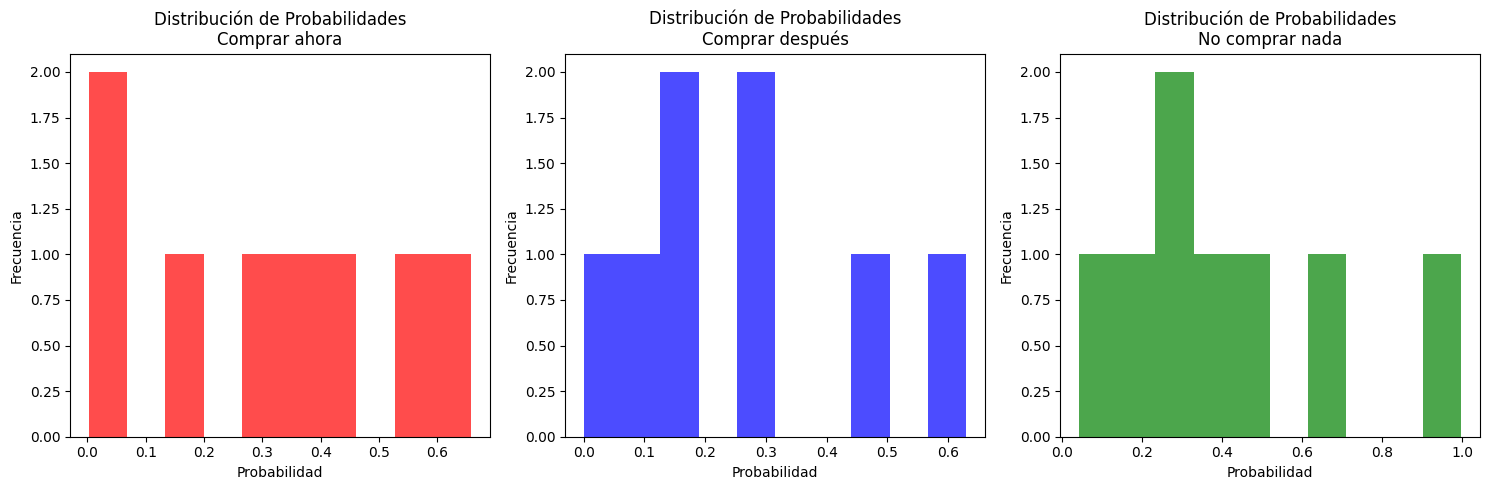


Casos con mayor incertidumbre (probabilidades más equilibradas):
    Comprar ahora  Comprar después  No comprar nada
6          0.4288           0.0879           0.4833
4          0.5509           0.1569           0.2922
15         0.3397           0.2774           0.3829
23         0.3119           0.4999           0.1882


In [11]:
# 3. PROBABILIDADES PREDICHAS
print("\n" + "="*60)
print("3. PROBABILIDADES PREDICHAS")
print("="*60)

# Crear DataFrame con probabilidades
probabilidades_df = pd.DataFrame(y_pred_proba, columns=class_names)
probabilidades_df.index = X_test.index

print("Probabilidades de cada clase para todas las muestras de prueba:")
print(probabilidades_df.round(4))

print("\nEstadísticas de las probabilidades:")
print(probabilidades_df.describe().round(4))

# Visualizar distribución de probabilidades
plt.figure(figsize=(15, 5))

for i, clase in enumerate(class_names):
    plt.subplot(1, 3, i+1)
    plt.hist(probabilidades_df[clase], bins=10, alpha=0.7, 
             color=['red', 'blue', 'green'][i])
    plt.title(f'Distribución de Probabilidades\n{clase}')
    plt.xlabel('Probabilidad')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Mostrar casos con mayor incertidumbre (probabilidades más cercanas)
print("\nCasos con mayor incertidumbre (probabilidades más equilibradas):")
max_proba = probabilidades_df.max(axis=1)
uncertain_cases = probabilidades_df[max_proba < 0.6]  # Casos donde la máxima probabilidad < 60%
print(uncertain_cases.round(4))


4. COEFICIENTES DEL MODELO
Interceptos (bias) para cada clase:
                 Intercepto
Comprar ahora        0.5269
Comprar después     -0.0225
No comprar nada     -0.5044

Coeficientes para cada clase:
                          Comprar ahora  Comprar después  No comprar nada
Sexo (0:hombre, 1:mujer)        -0.4136           0.1727           0.2409
Edad                            -0.3526           0.3017           0.0510
Tiempo en tienda online         -0.4634          -0.9539           1.4173


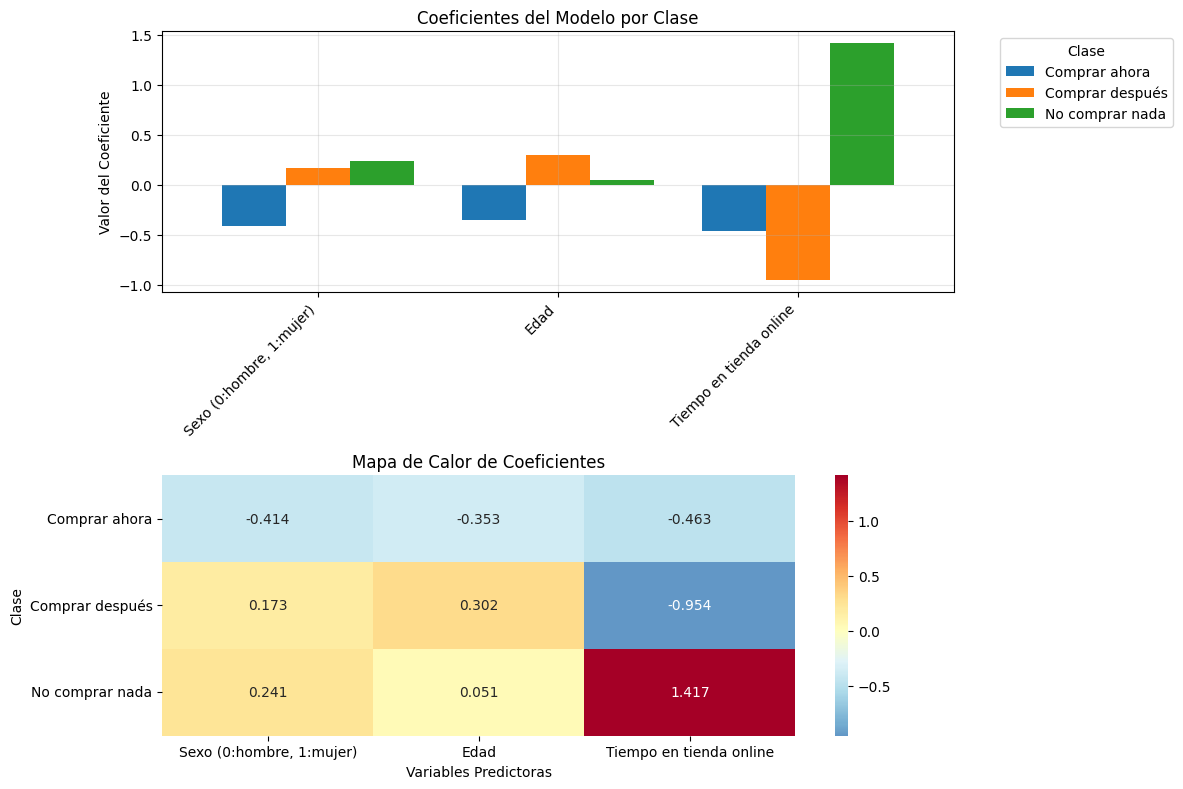


Análisis de magnitud de coeficientes (valores absolutos):
Importancia promedio de variables:
Tiempo en tienda online     0.9449
Sexo (0:hombre, 1:mujer)    0.2757
Edad                        0.2351
dtype: float64


In [12]:
# 4. COEFICIENTES DEL MODELO
print("\n" + "="*60)
print("4. COEFICIENTES DEL MODELO")
print("="*60)

# Obtener coeficientes e intercepto
coeficientes = logistic_model.coef_
intercepto = logistic_model.intercept_
feature_names = ['Sexo (0:hombre, 1:mujer)', 'Edad', 'Tiempo en tienda online']

print("Interceptos (bias) para cada clase:")
intercept_df = pd.DataFrame({'Intercepto': intercepto}, 
                          index=class_names)
print(intercept_df.round(4))

print(f"\nCoeficientes para cada clase:")
coef_df = pd.DataFrame(coeficientes.T, 
                      columns=class_names,
                      index=feature_names)
print(coef_df.round(4))

# Visualizar coeficientes
plt.figure(figsize=(12, 8))

# Gráfico de barras para coeficientes
plt.subplot(2, 1, 1)
coef_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Coeficientes del Modelo por Clase')
plt.ylabel('Valor del Coeficiente')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Clase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Mapa de calor de coeficientes
plt.subplot(2, 1, 2)
sns.heatmap(coef_df.T, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.3f', cbar=True)
plt.title('Mapa de Calor de Coeficientes')
plt.ylabel('Clase')
plt.xlabel('Variables Predictoras')

plt.tight_layout()
plt.show()

# Análisis de importancia de variables
print(f"\nAnálisis de magnitud de coeficientes (valores absolutos):")
coef_abs = np.abs(coef_df)
importancia = coef_abs.mean(axis=1).sort_values(ascending=False)
print("Importancia promedio de variables:")
print(importancia.round(4))

# 5. INTERPRETACIÓN Y CONCLUSIONES

## Interpretación de los Resultados Obtenidos:

### **1. Rendimiento del Modelo:**
- La matriz de confusión nos muestra cómo el modelo clasifica cada tipo de comportamiento de compra
- El reporte de clasificación proporciona métricas de precisión, recall y F1-score para evaluar la calidad del modelo
- La precisión general del modelo indica qué tan bien puede predecir los hábitos de compra

### **2. Probabilidades Predichas:**
- Las probabilidades muestran la confianza del modelo en cada predicción
- Valores cercanos a 0.33 (1/3) indican alta incertidumbre entre las tres clases
- Probabilidades altas (>0.8) indican predicciones muy confiables

### **3. Análisis de Coeficientes:**

#### **Interpretación por Variable:**

**Sexo (0:hombre, 1:mujer):**
- Coeficientes positivos → las mujeres tienen mayor probabilidad para esa clase
- Coeficientes negativos → los hombres tienen mayor probabilidad para esa clase

**Edad:**
- Coeficientes positivos → mayor edad aumenta la probabilidad de esa clase
- Coeficientes negativos → menor edad aumenta la probabilidad de esa clase

**Tiempo en tienda online:**
- Coeficientes positivos → más tiempo aumenta la probabilidad de esa clase
- Coeficientes negativos → menos tiempo aumenta la probabilidad de esa clase

### **4. Factores Influyentes:**
- La variable con mayor magnitud promedio de coeficientes es la más influyente
- Los signos de los coeficientes indican la dirección del efecto
- La regularización ayuda a evitar el sobreajuste del modelo

### **5. Implicaciones para el Negocio:**
- Identificar perfiles de clientes con mayor probabilidad de compra inmediata
- Personalizar estrategias de marketing según el comportamiento predicho
- Optimizar la experiencia del usuario en la tienda online
- Desarrollar campañas dirigidas para convertir "compradores tardíos" en "compradores inmediatos"

In [13]:
# EJEMPLO PRÁCTICO DE PREDICCIÓN
print("="*60)
print("EJEMPLO PRÁCTICO: NUEVAS PREDICCIONES")
print("="*60)

# Crear nuevos casos de ejemplo para predecir
nuevos_casos = pd.DataFrame({
    'Sexo': ['mujer', 'hombre', 'mujer', 'hombre'],
    'Edad': [25, 45, 35, 20],
    'Tiempo en la tienda online': [30, 15, 60, 90]
})

print("Nuevos casos a predecir:")
print(nuevos_casos)

# Preprocesar los nuevos casos
nuevos_casos_processed = nuevos_casos.copy()
nuevos_casos_processed['Sexo_encoded'] = le_sexo.transform(nuevos_casos['Sexo'])

# Preparar X para predicción
X_nuevos = nuevos_casos_processed[['Sexo_encoded', 'Edad', 'Tiempo en la tienda online']]

# Normalizar usando el mismo scaler
X_nuevos_scaled = X_nuevos.copy()
X_nuevos_scaled[columns_to_scale] = scaler.transform(X_nuevos[columns_to_scale])

# Hacer predicciones
predicciones = logistic_model.predict(X_nuevos_scaled)
probabilidades = logistic_model.predict_proba(X_nuevos_scaled)

# Mostrar resultados
resultados = pd.DataFrame({
    'Sexo': nuevos_casos['Sexo'],
    'Edad': nuevos_casos['Edad'],
    'Tiempo_tienda': nuevos_casos['Tiempo en la tienda online'],
    'Predicción': [le_target.inverse_transform([pred])[0] for pred in predicciones]
})

# Agregar probabilidades
for i, clase in enumerate(class_names):
    resultados[f'Prob_{clase}'] = probabilidades[:, i]

print(f"\nResultados de las predicciones:")
print(resultados.round(4))

print(f"\n" + "="*60)
print("RESUMEN FINAL DEL ANÁLISIS COMPLETADO:")
print("✓ Matriz de confusión generada")
print("✓ Reporte de clasificación obtenido") 
print("✓ Probabilidades predichas calculadas")
print("✓ Coeficientes del modelo analizados")
print("✓ Interpretación de resultados realizada")
print("="*60)

EJEMPLO PRÁCTICO: NUEVAS PREDICCIONES
Nuevos casos a predecir:
     Sexo  Edad  Tiempo en la tienda online
0   mujer    25                          30
1  hombre    45                          15
2   mujer    35                          60
3  hombre    20                          90

Resultados de las predicciones:
     Sexo  Edad  Tiempo_tienda       Predicción  Prob_Comprar ahora  \
0   mujer    25             30    Comprar ahora              0.5066   
1  hombre    45             15  Comprar después              0.3855   
2   mujer    35             60  No comprar nada              0.1546   
3  hombre    20             90  No comprar nada              0.0402   

   Prob_Comprar después  Prob_No comprar nada  
0                0.3695                0.1240  
1                0.5912                0.0233  
2                0.0912                0.7543  
3                0.0031                0.9566  

RESUMEN FINAL DEL ANÁLISIS COMPLETADO:
✓ Matriz de confusión generada
✓ Reporte de clas